# Restaurent Data Analysis Level 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("Dataset.xlsx")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [5]:
top_cuisines = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(3)
)

print(top_cuisines)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [6]:
total_restaurents = len(df)
percentage = (top_cuisines / total_restaurents) * 100
print(percentage)

Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


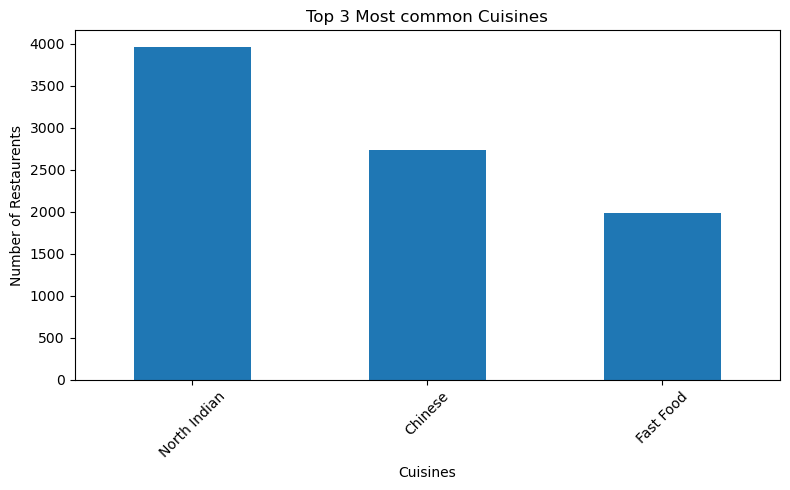

In [7]:
plt.figure(figsize=(8,5))
top_cuisines.plot(kind='bar')
plt.title("Top 3 Most common Cuisines")
plt.xlabel("Cuisines")
plt.ylabel("Number of Restaurents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 2 City analysis

In [8]:
city_count = df['City'].value_counts()
print(city_count.head())
top_city = city_count.idxmax()
print("City with highest number of restaurents:", top_city)

City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64
City with highest number of restaurents: New Delhi


In [11]:
avg_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
print(avg_rating)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [13]:
highest_rating_city = avg_rating.idxmax()
highest_rating = avg_rating.max()

print("City with highest average rating:", highest_rating_city)
print("Average Rating:", highest_rating)

City with highest average rating: Inner City
Average Rating: 4.9


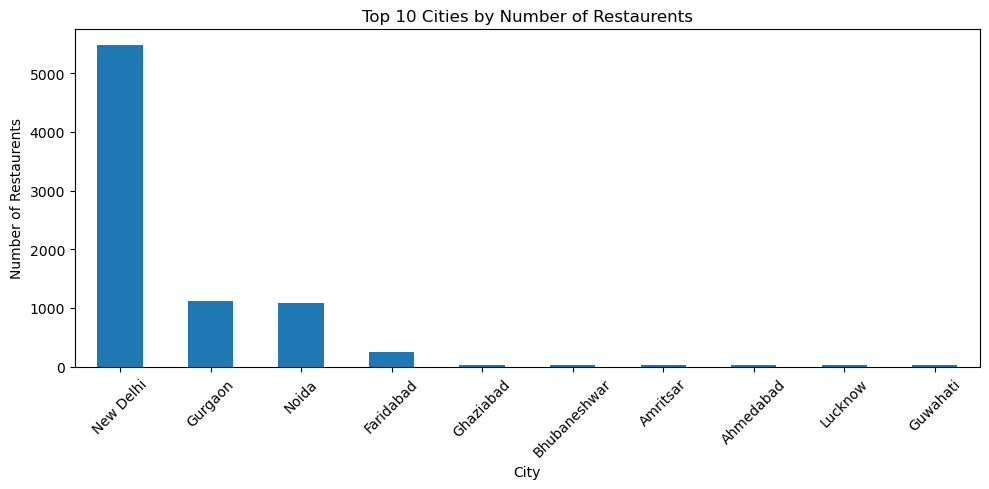

In [16]:
import matplotlib.pyplot as plt
city_count.head(10).plot(kind='bar',figsize=(10,5))
plt.title("Top 10 Cities by Number of Restaurents")
plt.xlabel("City")
plt.ylabel("Number of Restaurents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

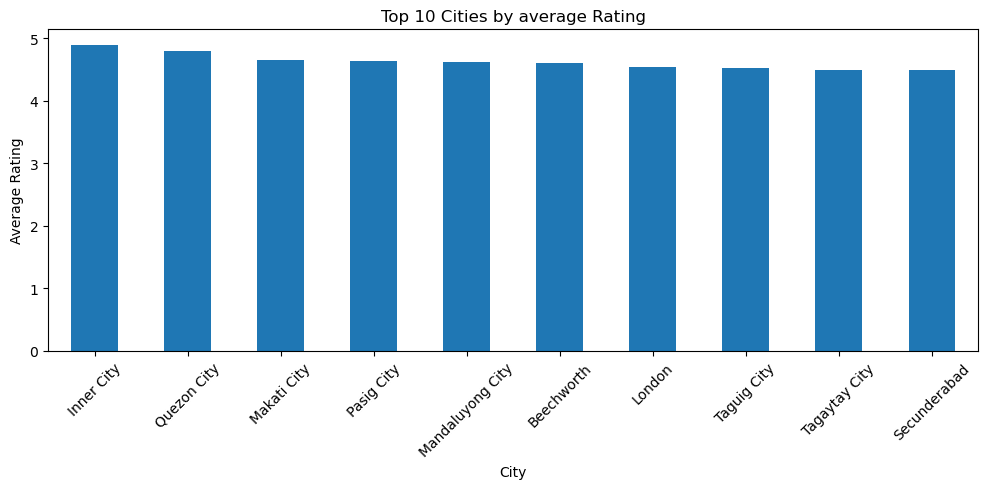

In [19]:
avg_rating.head(10).plot(kind='bar',figsize=(10,5))
plt.title("Top 10 Cities by average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 3 Price Range Distribution

In [20]:
price_count = df['Price range'].value_counts().sort_index()
print(price_count)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [21]:
price_percentage = (price_count / len(df))*100
print(price_percentage)

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


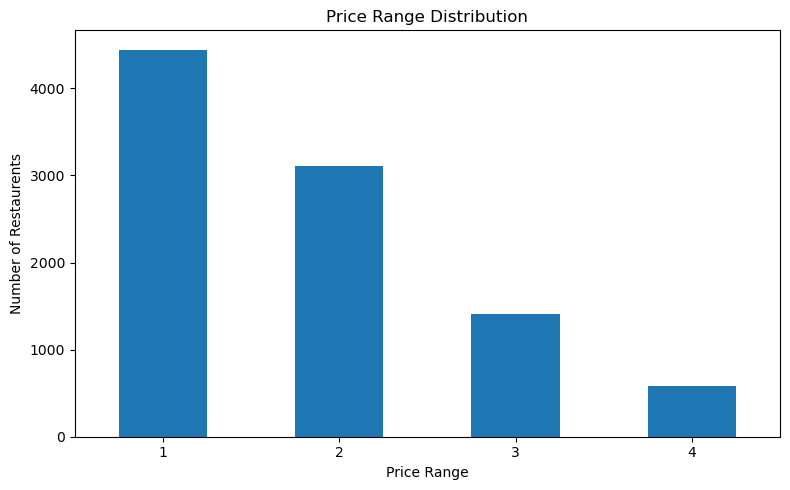

In [22]:
plt.figure(figsize=(8,5))
price_count.plot(kind='bar')
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

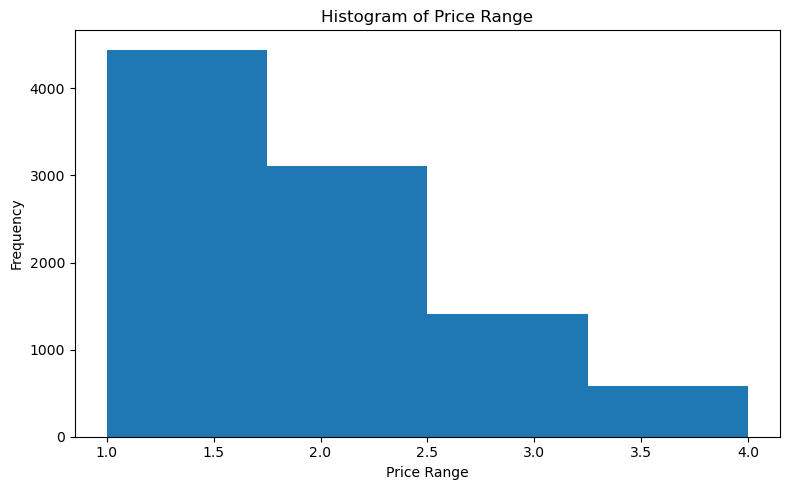

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df['Price range'], bins=4)
plt.title("Histogram of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Task 4 Online Delivery

In [25]:
delivery_count = df['Has Online delivery'].value_counts()
print(delivery_count)

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64


In [26]:
delivery_percentage = (delivery_count / len(df))*100
print(delivery_percentage)

Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64


In [28]:
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(avg_rating_delivery)

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


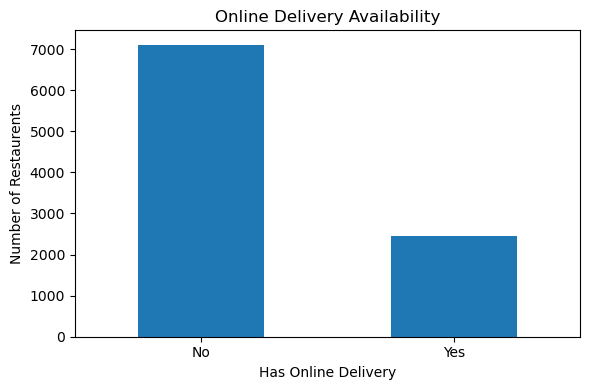

In [30]:
plt.figure(figsize=(6,4))
delivery_count.plot(kind='bar')
plt.title("Online Delivery Availability")
plt.xlabel("Has Online Delivery")
plt.ylabel("Number of Restaurents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

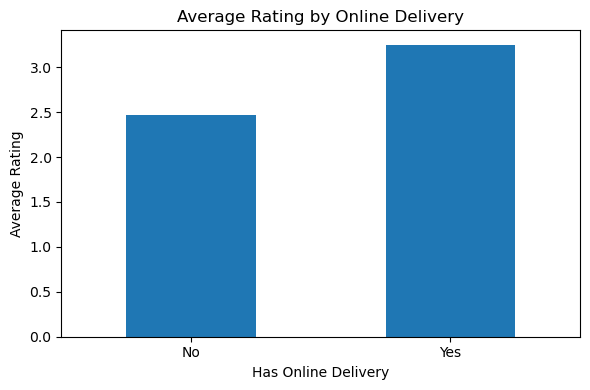

In [31]:
plt.figure(figsize=(6,4))
avg_rating_delivery.plot(kind='bar')
plt.title("Average Rating by Online Delivery")
plt.xlabel("Has Online Delivery")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()